<a href="https://colab.research.google.com/github/andaba2101/marketing_digital_ecommerce_validaci-n_hipotesis/blob/main/S9_Version_Student_Proyecto_Landing_Experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [ ]:
# importar librerías
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import levene

In [ ]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')
# df = pd.read_csv('https://drive.google.com/uc?export=download&id=15zGd_F-LzxCOcwNc74n_1x_o6OjAWYUV')

**Vista previa e información general del conjunto de datos**

In [ ]:
# mostrar las primeras 5 filas
df.head(5)

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [ ]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


✍️ **Comentario**:

    - No se observan valores nulos en ninguna columnna
    - La columna `date` es de tipo de dato object y debería de ser datetime64
    

In [ ]:
df['date'] = df['date'].astype('datetime64')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   user_id         40000 non-null  object        
 1   date            40000 non-null  datetime64[ns]
 2   landing         40000 non-null  object        
 3   region          40000 non-null  object        
 4   dispositivo     40000 non-null  object        
 5   traffic_source  40000 non-null  object        
 6   user_type       40000 non-null  object        
 7   converted       40000 non-null  int64         
 8   gasto           40000 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(6)
memory usage: 2.7+ MB


In [ ]:
variables_numericas = ['gasto']
variables_categoricas = ['converted', 'landing', 'region', 'dispositivo', 'traffic_source', 'user_type']

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

`converted` pese a ser binaria se puede catalogar como categorica sin romper el esquema de analisis

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [ ]:
print(f"usuarios duplicados: {df['user_id'].duplicated().sum()}")
print(f"usuarios unicos: {df['user_id'].nunique()}")

usuarios duplicados: 0
usuarios unicos: 40000


 **Variable `date`**  
Explorar rango de fechas

In [ ]:
# Resumen estadístico
df["date"].describe()

count                   40000
unique                     28
top       2026-01-24 00:00:00
freq                     1512
first     2026-01-01 00:00:00
last      2026-01-28 00:00:00
Name: date, dtype: object

In [ ]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01 00:00:00
Fecha máxima: 2026-01-28 00:00:00


**Variable `gasto` (numérica)**

In [ ]:
# Resumen estadístico
df["gasto"].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [ ]:
# Resumen estadístico de usuarios que se convirtieron
df["converted"].describe()

count    40000.00000
mean         0.14265
std          0.34972
min          0.00000
25%          0.00000
50%          0.00000
75%          0.00000
max          1.00000
Name: converted, dtype: float64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [ ]:
# Explorar variables categóricas y cómo se distribuyen
print("\nConteo de categorías:")
print(df[variables_categoricas].describe())


Conteo de categorías:
         converted
count  40000.00000
mean       0.14265
std        0.34972
min        0.00000
25%        0.00000
50%        0.00000
75%        0.00000
max        1.00000


converted  landing  region     dispositivo  traffic_source  user_type 
0          B        Norte      Mobile       Organic         Nuevo         907
           A        Norte      Mobile       Organic         Nuevo         861
                    Centro     Mobile       Organic         Nuevo         793
           B        Centro     Mobile       Organic         Nuevo         747
           A        Sur        Mobile       Organic         Nuevo         659
                                                                         ... 
1          A        Occidente  Desktop      Referral        Recurrente      3
           B        Oriente    Desktop      Referral        Recurrente      3
           A        Oriente    Desktop      Referral        Nuevo           2
                                                            Recurrente      2
                               Mobile       Referral        Recurrente      2
Length: 320, dtype: int64
____________________________
converted  landi

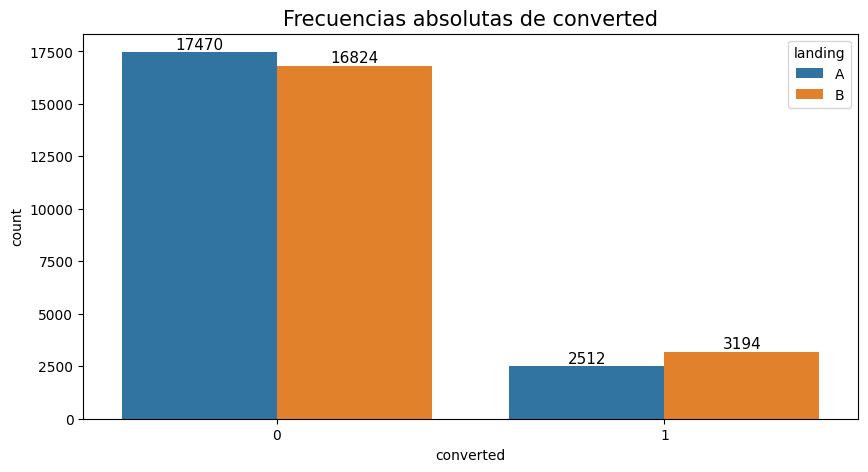

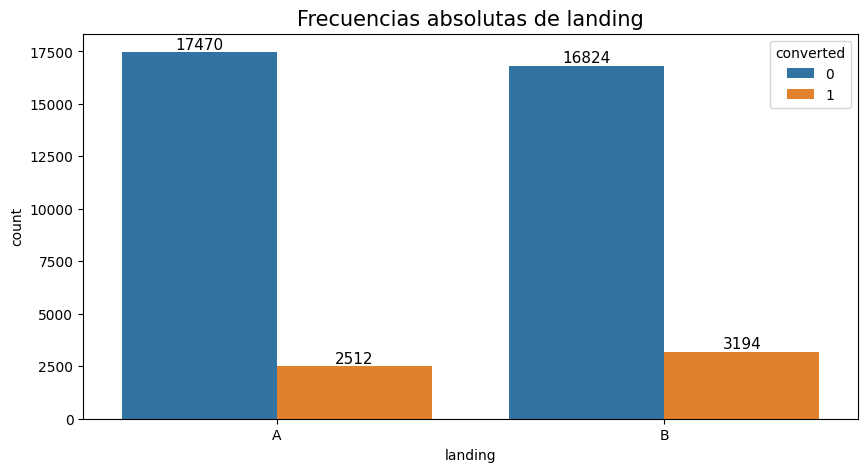

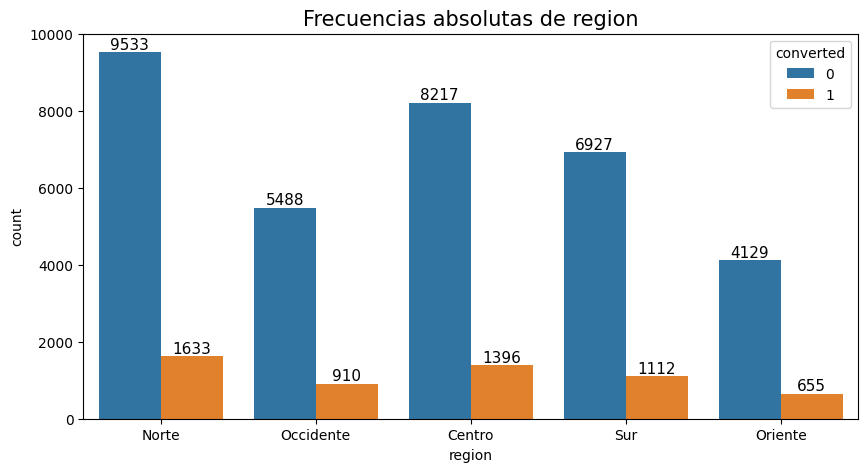

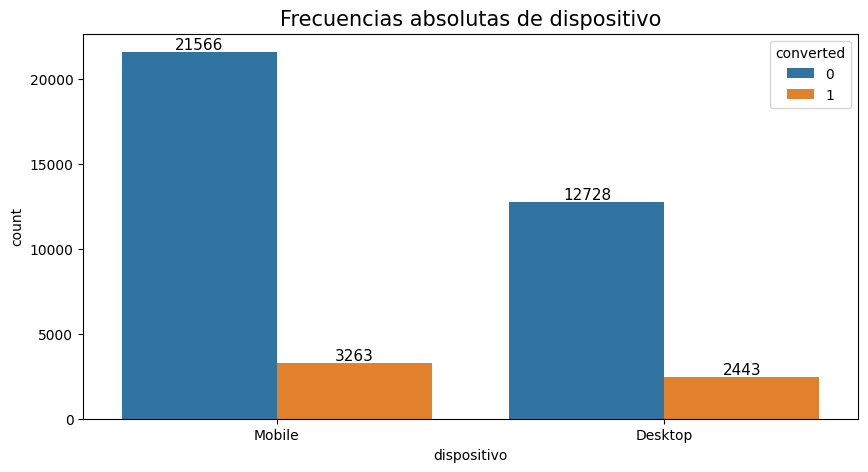

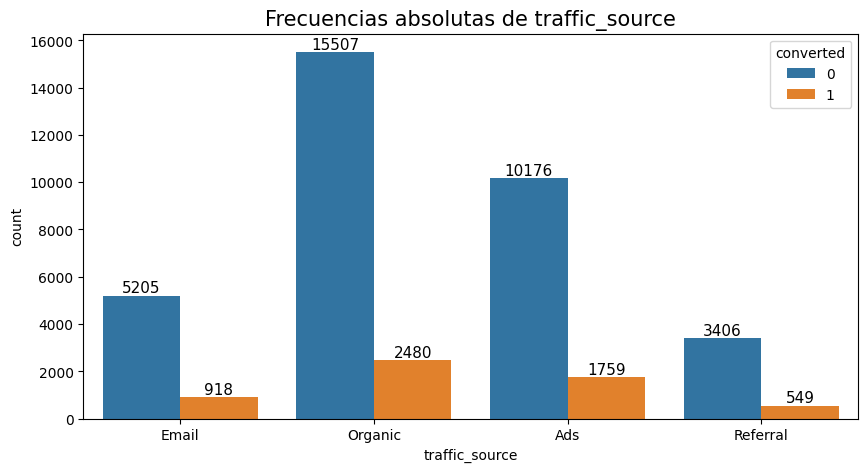

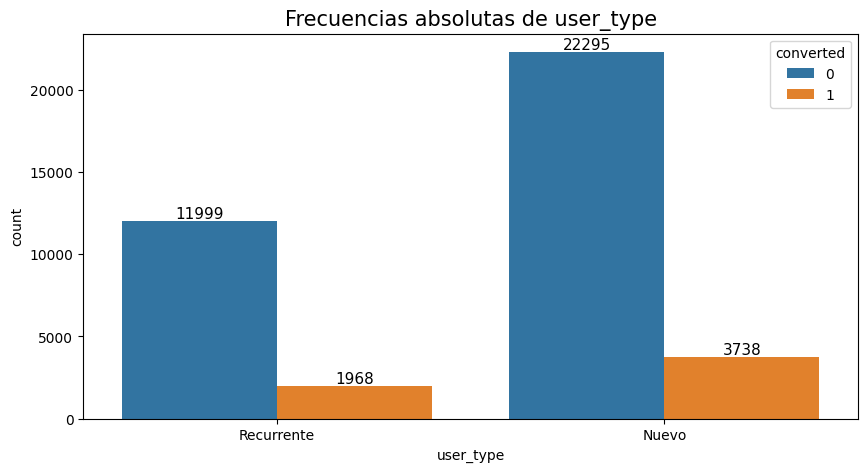

In [ ]:
print(df[variables_categoricas].value_counts())              # frecuencia absoluta
print('____________________________')
print(df[variables_categoricas].value_counts(normalize=True)) # frecuencia relativa (porcentaje)

def graficar_cat(df, columnas):
    for col in columnas:
        otra_col = [c for c in columnas if c != col][0]

        # Gráfico de barras agrupadas
        plt.figure(figsize=(10, 5))
        ax = sns.countplot(data=df, x=col, hue=otra_col)

        # Agregar valores
        for bar in ax.patches:        # Recorrer todas las barras del gráfico
            height = bar.get_height() # Obtener altura de barra (conteo de usuarios)
            ax.text(x=bar.get_x()+bar.get_width() /2, # Establecer coordenada X del texto (centro de la barra)
                y=height,                         # Establecer coordenada Y del texto
                s=height,                         # Valor a mostrar
                ha='center',                      # Alinear centro del texto en coordenada
                va='bottom',                      # Alinear parte inferior del texto en coordenada
                fontsize=11)                      # Tamaño de la fuente

        # Añadir detalles
        plt.title(f"Frecuencias absolutas de {col}", fontsize=15)


    return plt.show()

graficar_cat(df, variables_categoricas)

✍️ **Comentario**:
    - Todas las columnas tienen valores esperados, no se encontraron errores de tipeo ni variaciones anomalas en el conteo de datos


## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [ ]:
# Gasto por versión
gasto_A = df[(df['converted']==1) & (df['landing']=='A')]['gasto']
gasto_B = df[(df['converted']==1) & (df['landing']=='B')]['gasto']

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

(2512, 3194)

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀): el gasto promedio entre landing A y B es igual o al menos muy similar
- **Hipótesis alternativa (H₁):** El gasto promedio es diferente entre las paginas.

In [ ]:
# Prueba de varianzas iguales
l_stat, p_value_var = levene(gasto_A, gasto_B)

print(f"Estadístico de Levene: {l_stat:.6f}")
print(f"Valor p: {p_value_var:.6f}")

alpha = 0.05  # umbral de significancia

if p_value_var < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de varianzas diferentes (equal_var=False).")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia de varianzas diferentes (equal_var=True).")

print()

# Ejecutar prueba t y mostrar resultados
t_stat, p_value = ttest_ind(gasto_A, gasto_B, equal_var=False)

print(f"Estadístico t: {t_stat:.6f}")
print(f"Valor p: {p_value:.6f}")
print()

alpha = 0.05   # umbral de significancia
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de una diferencia.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.")



Estadístico de Levene: 29.176465
Valor p: 0.000000
Rechazamos la hipótesis nula: hay evidencia de varianzas diferentes (equal_var=False).

Estadístico t: -9.481011
Valor p: 0.000000

Rechazamos la hipótesis nula: hay evidencia de una diferencia.


In [ ]:
# Calcular promedios
media_gasto_A = gasto_A.mean()
media_gasto_B = gasto_B.mean()

print('El gasto promedio de los usuarios que se convirtieron en clientes en la página A es: ', media_gasto_A)
print('El gasto promedio de los usuarios que se convirtieron en clientes en la página B es: ', media_gasto_B)
print('La diferencia es de: ', media_gasto_B - media_gasto_A)

El gasto promedio de los usuarios que se convirtieron en clientes en la página A es:  61.0865724522293
El gasto promedio de los usuarios que se convirtieron en clientes en la página B es:  68.74536005009392
La diferencia es de:  7.658787597864624


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipotesis nula ya que aún habiendo evidencia de varianzas desiguales, el estadistico t evidencia que la diferencia entre el landing A y el B no es producto del azar haciendo que sea plausible esa discrepancia para tomar alguna decisión

El resultado se basa en una muestra, no en todos los usuarios.
Solo se consideraron ciertos usuarios.
El análisis asume observaciones independientes.

**Interpretación de negocio:**  
El gasto promedio aumenta en la pagina B en aproximadamente 7 dolares lo cual es significativo y dependiendo de los costes se debería tomar medidas acordes para seguir con estrategias tomadas en esa versión de la pagina para seguir promoviendo el gasto


---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen difere]ncias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** no existe diferencias en la tasa de conversión entre la pagina A y la pagina B
- **Hipótesis alternativa (H₁):** existe diferencia entre las paginas A y B

In [ ]:
# Número de usuarios convertidos por página
conversiones = df.groupby('landing')['converted'].sum()
totales = df.groupby('landing')['converted'].count()

# Total de usuarios por página
conteos = [conversiones['A'], conversiones['B']]
num_observaciones = [totales['A'], totales['B']]

print("Usuarios convertidos por página:\n", conteos)
print("\nTotal de usuarios por página:\n", num_observaciones)


Usuarios convertidos por página:
 [2512, 3194]

Total de usuarios por página:
 [19982, 20018]


In [ ]:
# Aplicar prueba

# Ejecutar el z-test para visualizar resultados
z_stat, p_value = proportions_ztest(conteos, num_observaciones)
print(f"Estadístico z: {z_stat:.5f}")
print(f"Valor P: {p_value:.7f}")

alpha = 0.05  # umbral de significancia
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de una diferencia.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.")

#---------------------------------------------------------------------------------------------
# Obtener tasa o porcentaje de éxito por grupo
tasa_A = conteos[0] / num_observaciones[0]
tasa_B = conteos[1] / num_observaciones[1]

print(f"\nTasa Pagina A: {tasa_A:.2%}")
print(f"Tasa Pagina B: {tasa_B:.2%}")
print(f"Diferencia: {tasa_B - tasa_A:.2%}")


Estadístico z: -9.67736
Valor P: 0.0000000
Rechazamos la hipótesis nula: hay evidencia de una diferencia.

Tasa Pagina A: 12.57%
Tasa Pagina B: 15.96%
Diferencia: 3.38%


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipotesis nula debido a que la diferencia provista no se debe al azar

**Interpretación de negocio:**  
la pagina B no solo hace que se gaste más (como se observó con el t-test) sino que también induce a más clientes nuevos a comprar por primera vez por lo que sería un segundo indicador de que la pagina B se comporta mejor con el cliente

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** no hay asociación significativa entre la fuente de trafico y la conversión
- **Hipótesis alternativa (H₁):** existe una asociación entre la fuente de trafico y la conversión

In [ ]:

# Aplicar prueba

# Construir  tabla de contingencia
tabla = pd.crosstab(df['traffic_source'], df['converted'])
print(tabla)

# Ejecutar prueba chi-cuadrada
chi2_stat, p_value, dof, expected = chi2_contingency(tabla)
print(f"\nEstadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor P: {p_value:.3f}")

# Intepretar resultados
alpha = 0.05  # umbral de significancia

if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.")

print() #salto de línea

# Tabla de contingencia normalizada
print(pd.crosstab(df['traffic_source'], df['converted'], normalize='index') * 100)


converted           0     1
traffic_source             
Ads             10176  1759
Email            5205   918
Organic         15507  2480
Referral         3406   549

Estadístico chi-cuadrado: 8.662
Valor P: 0.034
Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.

converted               0          1
traffic_source                      
Ads             85.261835  14.738165
Email           85.007349  14.992651
Organic         86.212264  13.787736
Referral        86.118837  13.881163


In [ ]:
# Función mejorada y generalizable para calcular V de Cramér
from scipy.stats import chi2_contingency
def cramer_v(df, col_cat):
    for i, col_1 in enumerate(col_cat):
        for col_2 in col_cat[i+1:]:
            print(f"\nCorrelacion de la variable categorica {col_1}")
            # tabla de contingencia
            tabla = pd.crosstab(df[col_1], df[col_2])

            # calcular chi-cuadrado
            chi2, p_value, dof, expected = chi2_contingency(tabla)

            # calcular coeficiente V de Cramér
            n = tabla.values.sum()
            v = np.sqrt(chi2 / (n * (min(tabla.shape) -1)))
            print(f"\ncon la variable {col_2}:")
            print(v)
            print('_________________________________')


# Aplicar V de Cramér en variables categoricas
cramer_v(df, variables_categoricas)


Correlacion de la variable categorica converted

con la variable landing:
0.04831532667804828
_________________________________

Correlacion de la variable categorica converted

con la variable region:
0.010278341976512772
_________________________________

Correlacion de la variable categorica converted

con la variable dispositivo:
0.04101098787148789
_________________________________

Correlacion de la variable categorica converted

con la variable traffic_source:
0.014715730394205666
_________________________________

Correlacion de la variable categorica converted

con la variable user_type:
0.0035828932074786447
_________________________________

Correlacion de la variable categorica landing

con la variable region:
0.014057606516552168
_________________________________

Correlacion de la variable categorica landing

con la variable dispositivo:
0.0007391750702443745
_________________________________

Correlacion de la variable categorica landing

con la variable traffic_source:

### 📝 Conclusión e interpretación

**Decisión:**  
Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables."

Como el valor p (0.034) es menor que 0.05, se concluye que sí existe una asociación estadísticamente significativa entre la fuente de tráfico y la conversión. Es decir, el canal por el que llega el usuario sí parece influir en si convierte o no.

**Interpretación de negocio:**  
aunque la diferencia no sea azar, la magnitud de esa diferencia (14.74% vs 14.99% vs 13.79%) es tan pequeña que, en términos de negocio, no representa una diferencia relevante para decidir invertir mucho más en un canal que en otro. Con muestras muy grandes como esta, el chi-cuadrado se vuelve muy sensible y puede detectar diferencias diminutas como "estadísticamente significativas", aunque esas diferencias sean irrelevantes en la práctica.

La V de Cramer es exactamente el indicador correcto para sustentar esto ya que el chi-cuadrado y su valor p pese a decir que si existe una asociación (sí/no), no dicen qué tan fuerte es esa asociación. La V de Cramer sí mide la magnitud/fuerza de la relación en una escala de 0 a 1, que es justo lo que se necesita para hablar de significancia práctica para el negocio que en este caso es de solo el 0.0147 (1.47%) lo cual es muy débil para sostener cualquier desición practica.


## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** no hay asociación entre el tipo de usuario y la conversión
- **Hipótesis alternativa (H₁):** si hay un diferencia entre el tipo de usuario y en el hecho de que se convierta o no en cliente

In [ ]:
# Aplicar prueba

# Construir  tabla de contingencia
tabla = pd.crosstab(df['user_type'], df['converted'])
print(tabla)

converted       0     1
user_type              
Nuevo       22295  3738
Recurrente  11999  1968


In [ ]:
# Ejecutar prueba chi-cuadrada
chi2_stat, p_value, dof, expected = chi2_contingency(tabla)
print(f"\nEstadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor P: {p_value:.3f}")

# Intepretar resultados
alpha = 0.05  # umbral de significancia

if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.")

print() #salto de línea

# Tabla de contingencia normalizada
print(pd.crosstab(df['user_type'], df['converted'], normalize='index') * 100)



Estadístico chi-cuadrado: 0.513
Valor P: 0.474
No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.

converted           0          1
user_type                       
Nuevo       85.641301  14.358699
Recurrente  85.909644  14.090356


### 📝 Conclusión e interpretación

**Decisión:**  
No se rechaza la hipotesis nula al no haber evidencia de asociación entre el tipo de cliente y en que se convierta o no

**Interpretación de negocio:**  
El hecho de que una persona sea cliente nuevo o recurrente no se asocia con que compre en la tienda en el periodo observado, el cliente puede estar viendose influenciado por otras variables diferentes

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

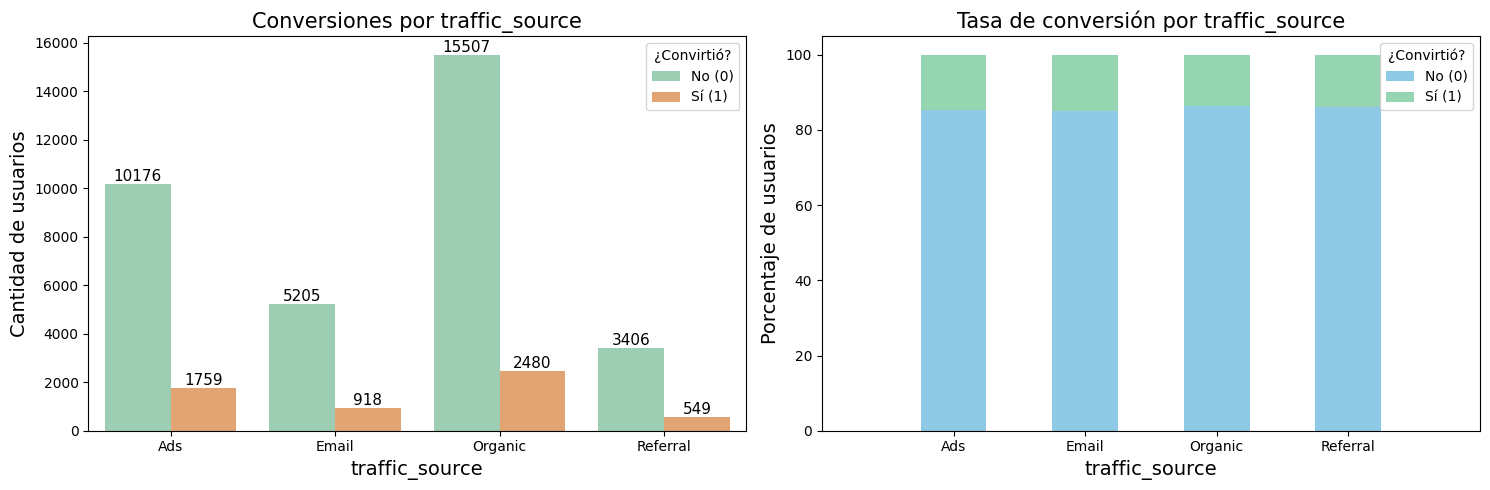

In [ ]:
def relacion_2(df, variables_categoricas, target='converted'):  # FUNCION GENERALIZABLE VISUALIZACIÓN DE RELACIONES ENTRE VARIABLES CATEGORICAS
    for col in variables_categoricas:
        if col == target:
            continue

        tab = pd.crosstab(df[col], df[target], normalize='index') * 100

        fig, axes = plt.subplots(1, 2, figsize=(15, 5))

        # Barras agrupadas
        ax = sns.countplot(data=df, x=col, hue=target, palette=["#95D5B2", "#F4A261"], ax=axes[0], order=tab.index)

        # Agregar valores
        for bar in ax.patches:        # Recorrer todas las barras del gráfico
            height = bar.get_height() # Obtener altura de barra (conteo de usuarios)
            ax.text(
                x=bar.get_x() + bar.get_width() / 2, # Establecer coordenada X del texto (centro de la barra)
                y=height,                            # Establecer coordenada Y del texto
                s=height,                            # Valor a mostrar
                ha='center',                         # Alinear centro del texto en coordenada
                va='bottom',                         # Alinear parte inferior del texto en coordenada
                fontsize=11                          # Tamaño de la fuente
            )

        axes[0].set_title(f"Conversiones por {col}", fontsize=15)
        axes[0].set_xlabel(f"{col}", fontsize=14)
        axes[0].set_ylabel('Cantidad de usuarios', fontsize=14)
        axes[0].legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])

        # Barras apiladas
        tab.plot(kind='bar', stacked=True, color=["#8ecae6", "#95d5b2"], ax=axes[1])
        axes[1].set_title(f"Tasa de conversión por {col}", fontsize=15)
        axes[1].set_xlabel(f"{col}", fontsize=14)
        axes[1].set_ylabel('Porcentaje de usuarios', fontsize=14)
        axes[1].set_xlim(-1, len(tab.index))
        axes[1].legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'], loc='upper right')
        axes[1].tick_params(axis='x', rotation=0)

        plt.tight_layout()
        plt.show()

traffic_source = ['traffic_source']
relacion_2(df, traffic_source, target='converted')

✍️ **Comentario**:

El Canal por el que llegó el usuario muestra en las graficas valores de conversión que resaltan el origen Organic como el más influyente, sin embargo eso no se observa en terminos relativos ya que si entran más clientes por ese canal pero su proporcion comparada con las otras fuentes es muy similar

Luego de usar la prueba Chi-cuadrada para validar si el patrón es estadísticamente relevante se encontró que si es relevante pero su magnitud es más bien floja, insignificante en terminos practicos. Lo que se está observando no es producto del azar pero no por ello es relevante para incentivar un canal sobre otro

“El gráfico muestra que Organic convierte más que los demás en terminos absolutos, pero en terminos relativos no.

La prueba de Chi-cuadrada confirma que existe la relación pese a ser con pequeñas diferencias. No es producto del azar pero es debil.”

### Relación entre el tipo de usuario y la conversión

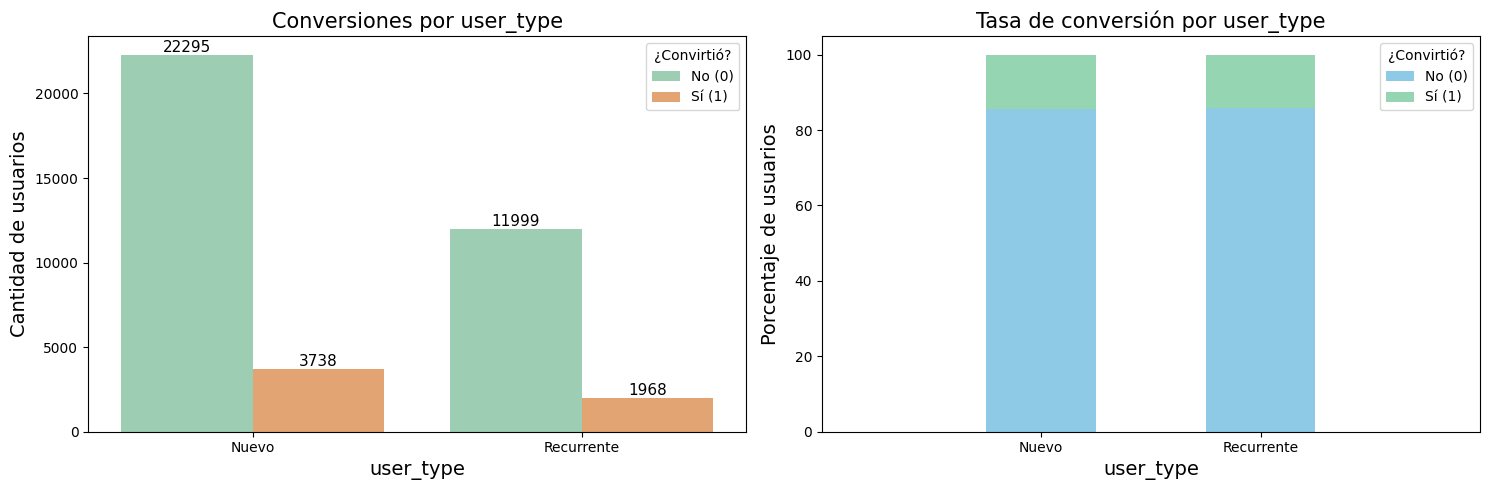

In [ ]:
user_type = ['user_type']
relacion_2(df, user_type, target='converted')

✍️ **Comentario**:

El Tipo de usuario según historial previo muestra en las graficas valores de conversión que resaltan a los nuevos como los más influyentes, sin embargo eso no se observa en terminos relativos ya que si se convierten más clientes que compran por primera vez pero su proporcion comparada con los que ya han comprado antes es muy similar

Luego de usar la prueba Chi-cuadrada para validar si el patrón es estadísticamente relevante se encontró que no es relevante. Lo que se está observando no evidencia de manera suficiente una asociación entre las variables.

“El gráfico muestra que Nuevo convierte más que los Recurrentes en terminos absolutos, pero en terminos relativos no.

La prueba de Chi-cuadrada no rechaza la hipótesis nula por lo que no hay evidencia suficiente de asociación entre estas variables.”


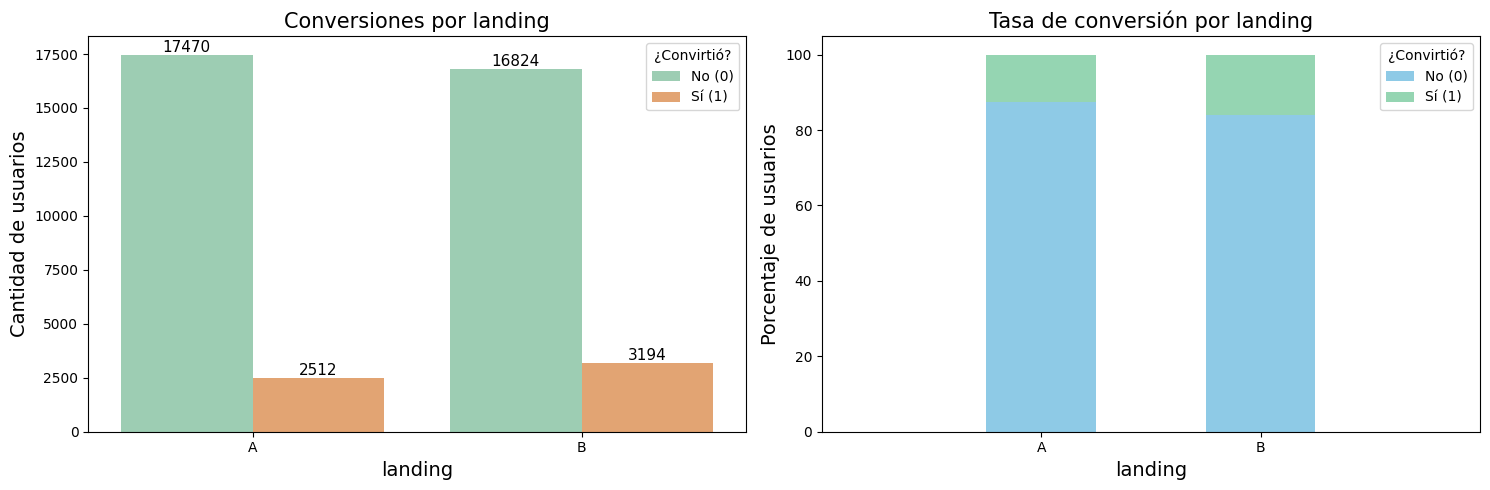

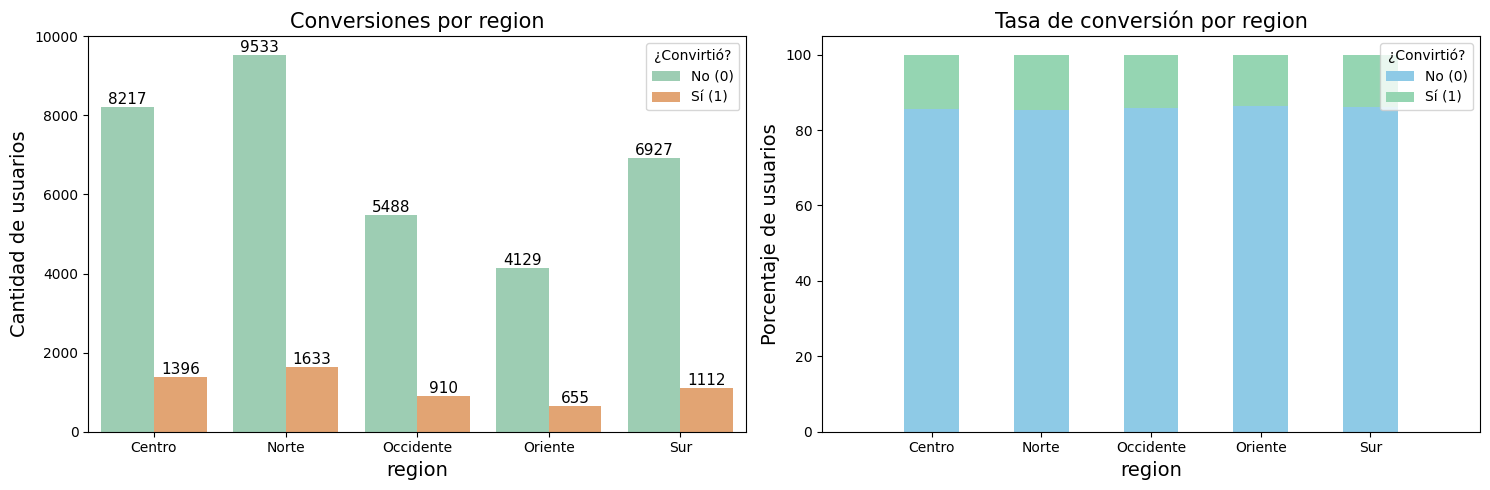

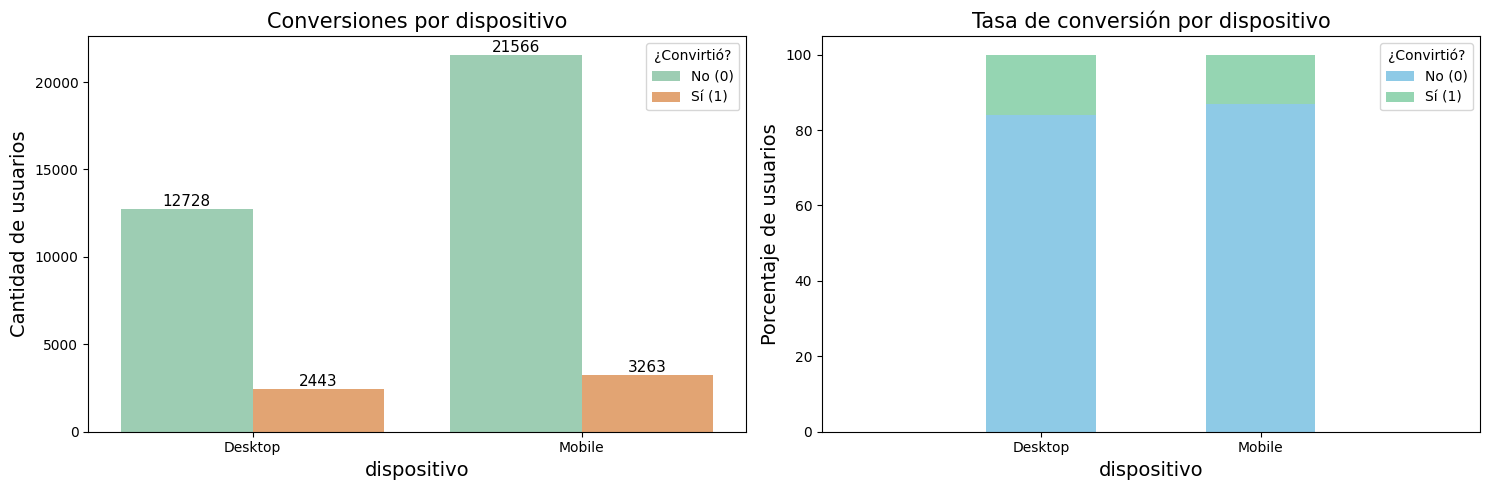

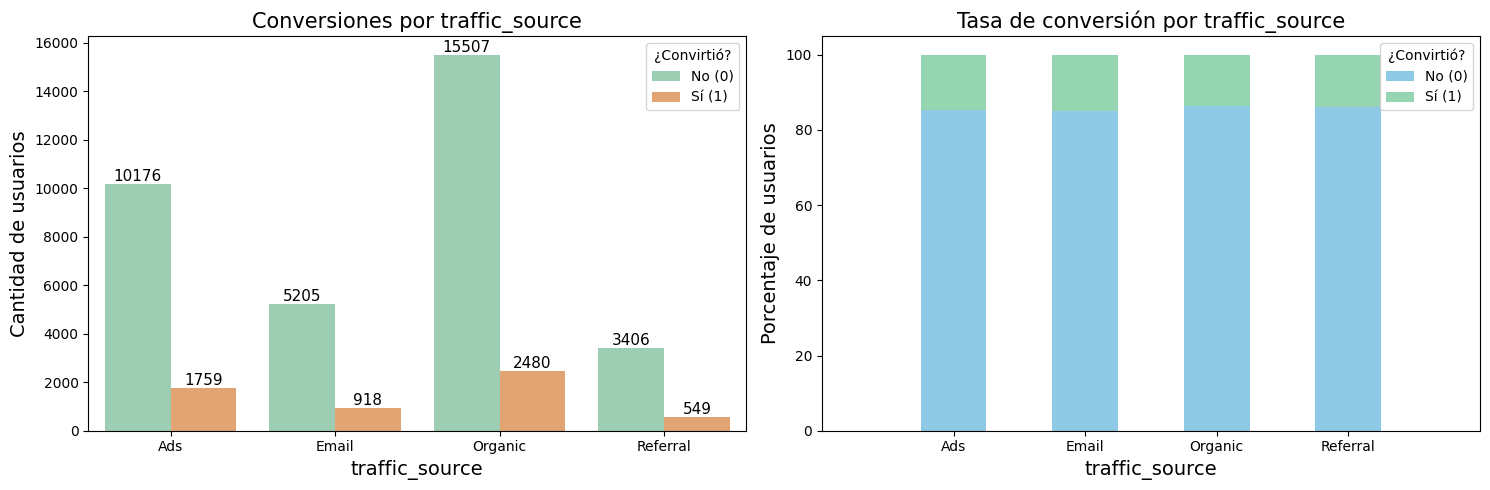

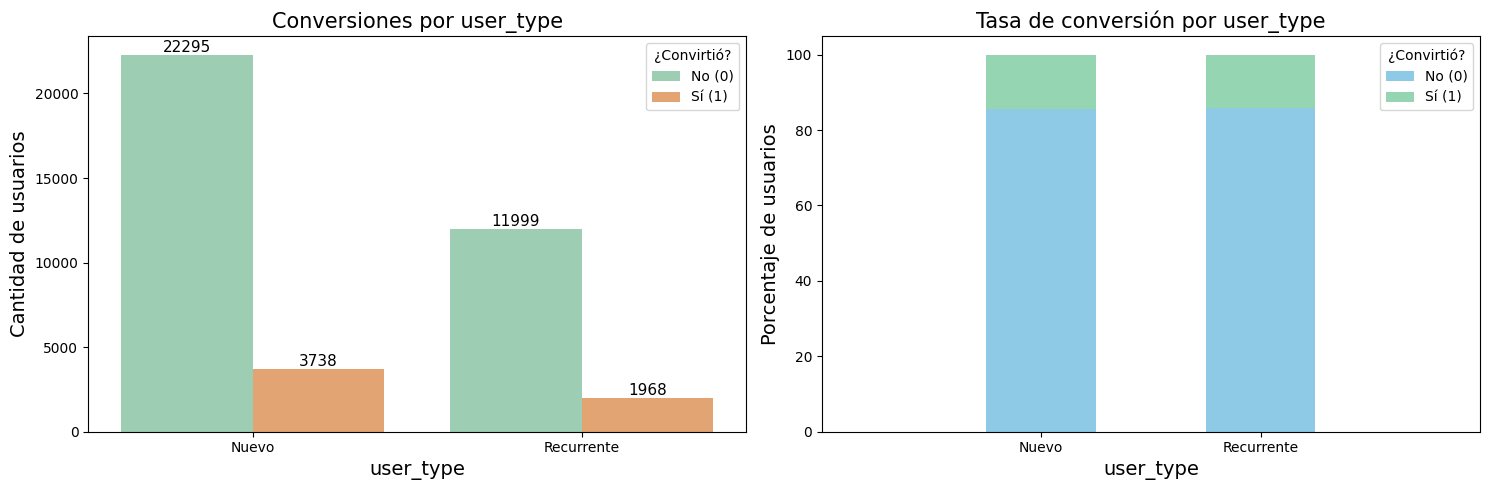

In [ ]:
relacion_2(df, variables_categoricas, target='converted')

✍️ **Comentario**:

Se hizo una función lo más generalizable posible que pueda, con tan solo poner las variables categoricas (o las columnas especificas que se deseen seleccionar) pueda realizar todo el procedimiento grafico sin riesgo de errores por tipeo. Para esto se incorporaron los codigos vistos en el sprint y ayuda de la IA para pulir detalles, con ellos se simplifica tiempo en la exposición de las relaciones entre variables categoricas que requieran crosstab (tablas de contigencia manuales).

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**
- Observación 1: El gasto promedio de los usuarios convertidos en la página A fue de 61.09 dólares, mientras que en la página B fue de 68.75 dólares, una diferencia de 7.66 dólares a favor de B

- Observación 2: La prueba de Levene detectó varianzas desiguales entre los grupos, por lo que se aplicó un t-test de Welch; el resultado (t = -9.48, p < 0.001) confirma que la diferencia no se debe al azar.


**Interpretación:**

- La página B genera un mayor valor económico por usuario convertido. Dado que la diferencia es estadísticamente significativa y de magnitud considerable (~12.5% más gasto), se recomienda evaluar los costos de implementación de B frente a este incremento en ingresos por conversión.

_________________________________________________________________________________________________________________________
**Tasa de conversión:**

- Observación 1: La tasa de conversión en la página A fue de 12.57%, frente a 15.96% en la página B, una diferencia de 3.38 puntos porcentuales.

- Observación 2: La prueba z de proporciones arrojó un estadístico de -9.68 con p < 0.001, rechazando la hipótesis nula de igualdad de tasas.


**Interpretación:**

La página B no solo genera mayor gasto, sino que también convierte a más usuarios en clientes. Esto refuerza a B como la versión ganadora en dos dimensiones críticas del negocio: volumen de conversión y valor monetario.

#### 📊 **Segmentación por fuente de tráfico**
- La prueba chi-cuadrado mostró una asociación estadísticamente significativa entre traffic_source y converted (chi² = 8.662, p = 0.034), pero el coeficiente V de Cramér fue de apenas 0.0147.


**Interpretación:**

- Aunque el canal Organic muestra más conversiones en términos absolutos, las tasas relativas entre canales (Ads 14.74%, Email 14.99%, Organic 13.79%, Referral 13.88%) son prácticamente iguales. La asociación es real pero irrelevante en la práctica; no se justifica reasignar presupuesto de marketing entre canales basándose en esta variable.


#### 📊 **Segmentación por tipo de usuario**
- La prueba chi-cuadrado entre usertype y converted no fue significativa (chi² = 0.513, p = 0.474) en absoluto.


**Interpretación:**

- No existe evidencia de que ser usuario nuevo o recurrente se asocie con la probabilidad de conversión durante el periodo observado. La estrategia de landing page no necesita diferenciarse por historial del usuario.

- Las visualizaciones usadas (gráficos de barras absolutas y apiladas por categoría) respaldan visualmente los resultados de las pruebas estadísticas de los pasos anteriores, mostrando consistencia entre magnitud observada y significancia estadística.


#### 💡 **Recomendaciones de negocio:**
- Adoptar la página B como versión estándar del sitio: genera simultáneamente mayor tasa de conversión (+3.38 pp) y mayor gasto promedio por cliente (+7.66 USD), ambos resultados estadísticamente robustos.

- No priorizar inversión diferenciada por fuente de tráfico: aunque existe una asociación estadística entre canal y conversión, su efecto práctico es inapreciable (V de Cramér ≈ 0.015); es más eficiente mantener la distribución actual de presupuesto entre Ads, Email, Organic y Referral al evitar potenciales riesgos.

- No segmentar la estrategia por tipo de usuario (nuevo vs. recurrente), ya que no hay diferencia significativa en su comportamiento de conversión; los recursos de personalización pueden enfocarse en otras variables con mayor poder explicativo.

- Antes de escalar la implementación de B, contrastar el incremento en gasto/conversión con los costos operativos o de desarrollo asociados a esa versión, para confirmar que el retorno neto sea positivo.

- Las demás variables categoricar presentan comportamientos similares a la observada en fuente de trafico con conversion.

In [ ]:
'Link del repositorio: https://github.com/andaba2101/marketing_digital_ecommerce_validaci-n_hipotesis.git'

'Link del repositorio: https://github.com/andaba2101/marketing_digital_ecommerce_validaci-n_hipotesis.git'